<a href="https://colab.research.google.com/github/Gabriellemga/Python_Data_Science_Alura/blob/main/Dados_geograficos_visualiza%C3%A7%C3%A3o_com_folium/Visualiza%C3%A7%C3%A3o_com_folium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01-Conhecendo o Folium

## Explorando dados geográficos

In [ ]:
import geopandas as gpd

In [ ]:
rj = gpd.read_file('/content/drive/MyDrive/rj_setores_censitarios/RJ_setores_censitários.shp')
rj.head()

,ID,CD_GEOCODI,TIPO,CD_GEOCODB,NM_BAIRRO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO,geometry
0,43773,330025805000046,URBANO,None,None,33002580500,None,330025805,ARRAIAL DO CABO,3300258,ARRAIAL DO CABO,LAGOS,BAIXADAS,"POLYGON ((-42.01954 -22.96936, -42.02059 -22.9..."
1,43774,330025805000047,URBANO,None,None,33002580500,None,330025805,ARRAIAL DO CABO,3300258,ARRAIAL DO CABO,LAGOS,BAIXADAS,"POLYGON ((-42.02282 -22.96769, -42.0229 -22.96..."
2,43775,330025805000048,URBANO,None,None,33002580500,None,330025805,ARRAIAL DO CABO,3300258,ARRAIAL DO CABO,LAGOS,BAIXADAS,"POLYGON ((-42.16022 -22.9474, -42.16241 -22.94..."
3,43776,330025805000049,URBANO,None,None,33002580500,None,330025805,ARRAIAL DO CABO,3300258,ARRAIAL DO CABO,LAGOS,BAIXADAS,"POLYGON ((-42.17397 -22.94625, -42.17588 -22.9..."
4,43777,330025805000050,URBANO,None,None,33002580500,None,330025805,ARRAIAL DO CABO,3300258,ARRAIAL DO CABO,LAGOS,BAIXADAS,"POLYGON ((-42.17588 -22.94609, -42.17848 -22.9..."


In [ ]:
rj.plot()

In [ ]:
cidade_rio = rj[rj['NM_MUNICIP'] == 'RIO DE JANEIRO']
cidade_rio.head()

,ID,CD_GEOCODI,TIPO,CD_GEOCODB,NM_BAIRRO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO,geometry
10708,56651,330455705080006,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO,"POLYGON ((-43.19949 -22.92454, -43.19953 -22.9..."
10709,56652,330455705080007,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO,"POLYGON ((-43.19795 -22.91829, -43.19819 -22.9..."
10710,56653,330455705080008,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO,"POLYGON ((-43.19858 -22.91876, -43.19888 -22.9..."
10711,56654,330455705080009,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO,"POLYGON ((-43.19879 -22.91937, -43.19879 -22.9..."
10712,56655,330455705080010,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO,"POLYGON ((-43.19791 -22.92028, -43.19791 -22.9..."


In [ ]:
cidade_rio.plot()

## Visualizando diferentes camadas

A biblioteca Folium permite a criação da visualização de mapas a partir de camadas. A primeira delas é a camada de fundo de mapa, que é composta por elementos essenciais em uma visualização cartográfica porque fornece o contexto geográfico para entender e analisar os dados que serão apresentados no mapa.

Por padrão, são disponibilizadas diversas camadas, que podem ser encontradas diretamente na [documentação da biblioteca](https://python-visualization.github.io/folium/latest/reference.html), na descrição do método Map():

OpenStreetMap

Mapbox Bright (Com níveis de zoom limitados)

CartoDB Positron

CartoDB Dark Matter

Além dos tipos de visualização padrão, podemos explorar camadas personalizadas da [Leaflet](https://leaflet-extras.github.io/leaflet-providers/preview/), que é uma biblioteca JavaScript usada para criar mapas interativos na internet e serve como base de construção do Folium.

In [ ]:
import folium

In [ ]:
mapa_rio = folium.Map(location=[-22, -43], zoom_start=8)
mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [-22, -43],
                      zoom_start = 8,
                      tiles='OpenStreetMap')

mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [-22, -43],
                      zoom_start = 8,
                      tiles='OpenStreetMap',
                      name = 'Stamen')

folium.TileLayer('cartodbpositron', name = 'Positron').add_to(mapa_rio)
folium.TileLayer('cartodbdark_matter', name = 'Dark').add_to(mapa_rio)
folium.TileLayer('https://{s}.tile-cyclosm.openstreetmap.fr/cyclosm/{z}/{x}/{y}.png', name = 'OSM',
                 attr = '<a href="https://github.com/cyclosm/cyclosm-cartocss-style/releases" title="CyclOSM - Open Bicycle render">CyclOSM</a> | Map data: &copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors').add_to(mapa_rio)

folium.LayerControl().add_to(mapa_rio)

mapa_rio.save('mapa_rio.html')

mapa_rio

## Dividindo o mapa em regiões

In [ ]:
bairros_rio = cidade_rio.dissolve(by = 'NM_BAIRRO')
bairros_rio.head(4)

,geometry,ID,CD_GEOCODI,TIPO,CD_GEOCODB,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO
NM_BAIRRO,,,,,,,,,,,,,
Abolição,"POLYGON ((-43.30094 -22.89123, -43.30095 -22.8...",59926,330455705170481,URBANO,330455705060,33045570517,MÉIER,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
Acari,"POLYGON ((-43.34222 -22.82782, -43.34253 -22.8...",65174,330455705300052,URBANO,330455705138,33045570530,PAVUNA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
Alto da Boa Vista,"POLYGON ((-43.29429 -22.97967, -43.29421 -22.9...",58519,330455705130289,URBANO,330455705031,33045570513,TIJUCA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
Anchieta,"POLYGON ((-43.41002 -22.83423, -43.41015 -22.8...",64367,330455705270062,URBANO,330455705125,33045570527,ANCHIETA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO


In [ ]:
mapa_rio = folium.Map(location = [-22, -43],
                      zoom_start = 8,
                      tiles = 'cartodbpositron')

folium.GeoJson(bairros_rio).add_to(mapa_rio)
mapa_rio

In [ ]:
cidade = cidade_rio.dissolve(by = 'NM_MUNICIP')
cidade.head()

,geometry,ID,CD_GEOCODI,TIPO,CD_GEOCODB,NM_BAIRRO,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MICRO,NM_MESO
NM_MUNICIP,,,,,,,,,,,,,
RIO DE JANEIRO,"MULTIPOLYGON (((-43.69721 -22.98559, -43.69753...",56651,330455705080006,URBANO,330455705005,Catumbi,33045570508,RIO COMPRIDO,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO


In [ ]:
mapa_rio = folium.Map(location = [-22, -43],
                      zoom_start = 8,
                      tiles = 'cartodbpositron')

folium.GeoJson(cidade).add_to(mapa_rio)
mapa_rio

In [ ]:
subdistritos = cidade_rio.dissolve(by = 'NM_SUBDIST')
subdistritos.head(4)

,geometry,ID,CD_GEOCODI,TIPO,CD_GEOCODB,NM_BAIRRO,CD_GEOCODS,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO
NM_SUBDIST,,,,,,,,,,,,,
ANCHIETA,"POLYGON ((-43.39713 -22.84397, -43.39693 -22.8...",63838,330455705270028,URBANO,330455705124,Guadalupe,33045570527,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
BANGU,"POLYGON ((-43.50491 -22.88582, -43.50497 -22.8...",62027,330455705220201,URBANO,330455705099,Bangu,33045570522,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
BARRA DA TIJUCA,"MULTIPOLYGON (((-43.51347 -23.06586, -43.51362...",64722,330455705290104,URBANO,330455705131,Barra da Tijuca,33045570529,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
BOTAFOGO,"MULTIPOLYGON (((-43.20109 -22.96152, -43.20111...",56835,330455705090055,URBANO,330455705014,Botafogo,33045570509,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO


In [ ]:
mapa_rio = folium.Map(location = [-22, -43],
                      zoom_start = 8,
                      tiles = 'cartodbpositron')

folium.GeoJson(subdistritos).add_to(mapa_rio)
mapa_rio

# 02-Construindo um mapa de calor

## Removendo outiliers em imoveis

In [ ]:
import pandas as pd

In [ ]:
imoveis = pd.read_csv('https://raw.githubusercontent.com/Gabriellemga/Python_Data_Science_Alura/refs/heads/main/Dados_geograficos_visualiza%C3%A7%C3%A3o_com_folium/dados/dados.csv',
                      sep = '\t' )
imoveis.head()

,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000
4,85,Gávea,Rio de Janeiro,Rua Marquês de São Vicente,RJ,-14.235004,-51.925280,2,1,2,Apartamento,Venda,1800000


In [ ]:
imoveis = gpd.GeoDataFrame(imoveis, geometry = gpd.points_from_xy(imoveis['Longitude'], imoveis['Latitude']))
imoveis.head()

,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
0,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (-43.46295 -23.01646)
1,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (-43.33691 -22.9432)
2,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (-43.30052 -22.87385)
3,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (-43.4127 -22.98479)
4,85,Gávea,Rio de Janeiro,Rua Marquês de São Vicente,RJ,-14.235004,-51.925280,2,1,2,Apartamento,Venda,1800000,POINT (-51.92528 -14.235)


In [ ]:
base = cidade.plot()
imoveis.plot(ax = base, alpha = 0.2);

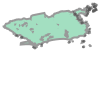

In [ ]:
cidade['geometry'].iloc[0]

In [ ]:
imoveis['geometry'].within(cidade['geometry'].iloc[0])

,0
0,True
1,True
2,True
3,True
4,False
...,...
4995,True
4996,True
4997,True
4998,True


In [ ]:
imoveis = imoveis[imoveis['geometry'].within(cidade['geometry'].iloc[0])]

In [ ]:
base = cidade.plot(color = 'white', edgecolor = 'black', figsize = (15,8))
imoveis.plot(ax = base, alpha = 0.2)

## Visualizando a concentração de imóveis

In [ ]:
from folium.plugins import HeatMap

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

HeatMap(data = imoveis[['Latitude', 'Longitude']]).add_to(mapa_rio)

mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

HeatMap(data = imoveis[['Latitude', 'Longitude']], name = 'Mapa de Calor').add_to(mapa_rio)
folium.GeoJson(cidade, name = 'Rio de Janeiro').add_to(mapa_rio)

folium.LayerControl().add_to(mapa_rio)

mapa_rio

## Melhorando o visual do HeatMap

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbdark_matter')

estilo = {'fillOpacity':0 ,'color' : '#ffffff', 'weight': 0.5}

HeatMap(data = imoveis[['Latitude', 'Longitude']], name = 'Mapa de Calor', radius = 20).add_to(mapa_rio)
folium.GeoJson(cidade, name = 'Rio de Janeiro', style_function= lambda x: estilo).add_to(mapa_rio)

folium.LayerControl().add_to(mapa_rio)

mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbdark_matter',
                      name = 'Dark')

estilo = {'fillOpacity':0 ,'color' : '#ffffff', 'weight': 0.5}

HeatMap(data = imoveis[['Latitude', 'Longitude']], name = 'Mapa de Calor', radius = 20).add_to(mapa_rio)
folium.GeoJson(bairros_rio, name = 'Rio de Janeiro', style_function= lambda x: estilo).add_to(mapa_rio)

estilo_borda_preta = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

HeatMap(data = imoveis[['Latitude', 'Longitude']], name = 'Mapa de Calor (vemelho)', radius = 20, gradient = {'0.0':'grey', '1.0':'red'}, show = False).add_to(mapa_rio)
folium.GeoJson(bairros_rio, name = 'Rio de Janeiro (borda preta)', style_function= lambda x: estilo_borda_preta, show = False).add_to(mapa_rio)

folium.TileLayer('cartodbpositron', name = 'Positron').add_to(mapa_rio)

folium.LayerControl().add_to(mapa_rio)

mapa_rio

## Filtrando o mapa por região

In [ ]:
bairros_rio.head()

In [ ]:
bairros_rio.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbdark_matter')

estilo = {'fillOpacity':0 ,'color' : '#ffffff', 'weight': 0.5}

HeatMap(data = imoveis[['Latitude', 'Longitude']], name = 'Mapa de Calor', radius = 20).add_to(mapa_rio)

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

folium.LayerControl().add_to(mapa_rio)

mapa_rio.save('mapa_calor_rio.html')

mapa_rio

# 03-Utilizando marcadores

## Inserindo marcadores

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

folium.GeoJson(cidade, name = 'Rio de Janeiro').add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']]
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)

mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

folium.GeoJson(cidade, name = 'Rio de Janeiro').add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = 'red')
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)
mapa_rio

## Classificando os imóveis com marcadores

In [ ]:
imoveis.describe()

,Area,Latitude,Longitude,Quartos,Suites,Vagas,Valor
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4.513000e+03
mean,121.512076,-22.952875,-43.275193,2.617771,0.925105,1.222025,1.382456e+06
std,88.566429,0.046873,0.094642,0.902083,0.922614,0.907701,1.841276e+06
min,15.000000,-23.031084,-43.678834,0.000000,0.000000,0.000000,8.000000e+04
25%,70.000000,-22.985222,-43.343578,2.000000,0.000000,1.000000,4.500000e+05
50%,92.000000,-22.963529,-43.238239,3.000000,1.000000,1.000000,8.000000e+05
75%,143.000000,-22.924173,-43.194280,3.000000,1.000000,2.000000,1.560000e+06
max,1147.000000,-22.788539,-43.159735,12.000000,5.000000,6.000000,3.000000e+07


In [ ]:
imoveis.insert(0, 'cor', pd.qcut(imoveis['Valor'], q = [0, 0.5, 0.75, 1], labels = ['green', 'orange', 'red']))

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

folium.GeoJson(cidade, name = 'Rio de Janeiro').add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa')
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)
mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

estilo = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa')
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)
mapa_rio

## Adicionando popups

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

estilo = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa'),
        popup = f'Área: {linha["Area"]} m², Valor: R$ {linha["Valor"]}'
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)
mapa_rio

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

estilo = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

amostra_imoveis = imoveis.sample(500)

amostra_imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa'),
        popup = folium.Popup(f'''<b>Bairro</b>: {linha["Bairro"]}<br>
                                <b>Área</b>: {linha["Area"]} m²<br>
                                <b>Valor</b>: R$ {linha["Valor"]},00<br>
                                <b>Quartos</b>: {linha["Quartos"]}
                            ''',
                             max_width = 200,
                             sticky = True)
    ).add_to(mapa_rio), axis = 1
)

folium.LayerControl().add_to(mapa_rio)
mapa_rio

## Marcadores clusterizados

In [ ]:
from folium.plugins import FastMarkerCluster

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

estilo = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

cluster = FastMarkerCluster(imoveis[['Latitude', 'Longitude']])
cluster.add_to(mapa_rio)
folium.LayerControl().add_to(mapa_rio)
mapa_rio

In [ ]:
from folium.plugins import MarkerCluster

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

estilo = {'fillOpacity':0 ,'color' : '#000000', 'weight': 0.5}

for indice, linha in bairros_rio.iterrows():
    bairro = gpd.GeoDataFrame(pd.DataFrame(linha).T, geometry= 'geometry', crs = 'EPSG:4674')
    folium.GeoJson(bairro, name = bairro.index[0], style_function= lambda x: estilo, tooltip = bairro.index[0]).add_to(mapa_rio)

cluster = MarkerCluster()

imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa'),
        popup = folium.Popup(f'''<b>Bairro</b>: {linha["Bairro"]}<br>
                                <b>Área</b>: {linha["Area"]} m²<br>
                                <b>Valor</b>: R$ {linha["Valor"]},00<br>
                                <b>Quartos</b>: {linha["Quartos"]}
                            ''',
                             max_width = 200,
                             sticky = True)
    ).add_to(cluster), axis = 1
)

cluster.add_to(mapa_rio)
folium.LayerControl().add_to(mapa_rio)
mapa_rio

# 04-Criando um mapa coropletico

# Georreferenciamento por bairro

In [ ]:
bairros_rio = bairros_rio.reset_index()
bairros_rio.head()

,NM_BAIRRO,geometry,ID,CD_GEOCODI,TIPO,CD_GEOCODB,CD_GEOCODS,NM_SUBDIST,CD_GEOCODD,NM_DISTRIT,CD_GEOCODM,NM_MUNICIP,NM_MICRO,NM_MESO
0,Abolição,"POLYGON ((-43.30094 -22.89123, -43.30095 -22.8...",59926,330455705170481,URBANO,330455705060,33045570517,MÉIER,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
1,Acari,"POLYGON ((-43.34222 -22.82782, -43.34253 -22.8...",65174,330455705300052,URBANO,330455705138,33045570530,PAVUNA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
2,Alto da Boa Vista,"POLYGON ((-43.29429 -22.97967, -43.29421 -22.9...",58519,330455705130289,URBANO,330455705031,33045570513,TIJUCA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
3,Anchieta,"POLYGON ((-43.41002 -22.83423, -43.41015 -22.8...",64367,330455705270062,URBANO,330455705125,33045570527,ANCHIETA,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO
4,Andaraí,"POLYGON ((-43.26797 -22.93775, -43.26729 -22.9...",58716,330455705140165,URBANO,330455705034,33045570514,VILA ISABEL,330455705,RIO DE JANEIRO,3304557,RIO DE JANEIRO,RIO DE JANEIRO,METROPOLITANA DO RIO DE JANEIRO


In [ ]:
for indice in range(len(bairros_rio)):
    display(imoveis[imoveis['geometry'].within(bairros_rio['geometry'].iloc[indice])])
    print(bairros_rio['NM_BAIRRO'].iloc[indice])

,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
218,green,57,Abolição,Rio de Janeiro,Rua Teixeira de Azevedo,RJ,-22.889072,-43.296670,2,0,1,Apartamento,Venda,240000,POINT (-43.29667 -22.88907)
2188,green,61,Abolição,Rio de Janeiro,Rua Paquequer,RJ,-22.880409,-43.301828,2,0,1,Apartamento,Venda,155000,POINT (-43.30183 -22.88041)
4395,green,60,Engenho de Dentro,Rio de Janeiro,Rua das Oficinas,RJ,-22.882278,-43.299704,2,1,1,Apartamento,Venda,337000,POINT (-43.2997 -22.88228)


Abolição


,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry


Acari


,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
4600,green,96,Alto da Boa Vista,Rio de Janeiro,Rua Raiz da Serra,RJ,-22.946699,-43.258067,3,1,1,Apartamento,Venda,590000,POINT (-43.25807 -22.9467)


...

Vista Alegre


,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
1677,green,75,Zumbi,Rio de Janeiro,Estrada do Rio Jequia,RJ,-22.823366,-43.175655,2,1,1,Apartamento,Venda,465000,POINT (-43.17565 -22.82337)
1950,green,62,Zumbi,Rio de Janeiro,Rua Serrão,RJ,-22.822149,-43.175481,2,0,1,Apartamento,Venda,420000,POINT (-43.17548 -22.82215)
4787,green,72,Zumbi,Rio de Janeiro,Estrada do Rio Jequia,RJ,-22.823143,-43.175587,2,1,1,Apartamento,Venda,395000,POINT (-43.17559 -22.82314)


Zumbi


,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry
373,green,46,Engenho de Dentro,Rio de Janeiro,Rua Borja Reis,RJ,-22.903784,-43.307729,2,0,1,Apartamento,Venda,230000,POINT (-43.30773 -22.90378)
1826,green,83,Engenho de Dentro,Rio de Janeiro,Rua Borja Reis,RJ,-22.903648,-43.308133,2,0,1,Apartamento,Venda,430000,POINT (-43.30813 -22.90365)
4228,green,80,Engenho de Dentro,Rio de Janeiro,Rua Eulina Ribeiro,RJ,-22.909304,-43.302428,3,0,1,Apartamento,Venda,249000,POINT (-43.30243 -22.9093)


Água Santa


In [ ]:
for indice in range(len(bairros_rio)):
    imoveis.loc[imoveis['geometry'].within(bairros_rio['geometry'].iloc[indice]), 'NM_BAIRRO'] = bairros_rio['NM_BAIRRO'].iloc[indice]

imoveis

,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,NM_BAIRRO
0,orange,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (-43.46295 -23.01646),Recreio dos Bandeirantes
1,green,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (-43.33691 -22.9432),Freguesia (Jacarepaguá)
2,green,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (-43.30052 -22.87385),Pilares
3,green,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (-43.4127 -22.98479),Barra da Tijuca
5,orange,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (-43.4775 -23.01893),Recreio dos Bandeirantes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,green,48,Campo Grande,Rio de Janeiro,Rua Josué de Barros,RJ,-22.878349,-43.550762,2,0,1,Apartamento,Venda,170000,POINT (-43.55076 -22.87835),Campo Grande
4996,green,75,Recreio dos Bandeirantes,Rio de Janeiro,Rua Le Corbusier,RJ,-23.024717,-43.487285,3,1,1,Apartamento,Venda,550000,POINT (-43.48729 -23.02472),Recreio dos Bandeirantes
4997,green,32,Jardim Botânico,Rio de Janeiro,Rua Getúlio das Neves,RJ,-22.959433,-43.206180,1,0,0,Apartamento,Venda,580000,POINT (-43.20618 -22.95943),Jardim Botânico
4998,green,85,Grajaú,Rio de Janeiro,Rua Jerônimo de Lemos,RJ,-22.918773,-43.260492,3,0,0,Apartamento,Venda,325000,POINT (-43.26049 -22.91877),Vila Isabel


## Extraindo estatísticas dos bairros

In [ ]:
imoveis.head()

,cor,Area,Bairro,Cidade,Endereco,Estado,Latitude,Longitude,Quartos,Suites,Vagas,Tipo,Transacao,Valor,geometry,NM_BAIRRO
0,orange,138,Recreio dos Bandeirantes,Rio de Janeiro,Rua Vicente Scofano,RJ,-23.016455,-43.462946,3,1,3,Apartamento,Venda,1095000,POINT (-43.46295 -23.01646),Recreio dos Bandeirantes
1,green,133,Freguesia (Jacarepaguá),Rio de Janeiro,Rua Potiguara,RJ,-22.943199,-43.336911,3,1,2,Apartamento,Venda,650000,POINT (-43.33691 -22.9432),Freguesia (Jacarepaguá)
2,green,46,Pilares,Rio de Janeiro,Rua Professor Carneiro Felipe,RJ,-22.873849,-43.300517,1,0,0,Apartamento,Venda,150000,POINT (-43.30052 -22.87385),Pilares
3,green,65,Barra da Tijuca,Rio de Janeiro,Avenida Salvador Allende,RJ,-22.984787,-43.412703,2,1,1,Apartamento,Venda,430000,POINT (-43.4127 -22.98479),Barra da Tijuca
5,orange,260,Recreio dos Bandeirantes,Rio de Janeiro,Rua Desembargador Paulo Alonso,RJ,-23.018927,-43.477505,3,1,2,Apartamento,Venda,1160000,POINT (-43.4775 -23.01893),Recreio dos Bandeirantes


In [ ]:
estatisticas_bairros = imoveis.groupby('NM_BAIRRO')[['Valor', 'Tipo', 'Area']].agg({'Valor':['min', 'mean', 'max'], 'Tipo': 'count', 'Area':['min', 'max']})
estatisticas_bairros.head()

Valor                          Tipo Area     
                      min           mean      max count  min  max
NM_BAIRRO                                                        
Abolição           155000  244000.000000   337000     3   57   61
Alto da Boa Vista  590000  590000.000000   590000     1   96   96
Anchieta            85000   85000.000000    85000     1   70   70
Andaraí            235000  524999.761905  1380000    42   35  230
Anil               100000  447524.285714   834000    21   48  205

In [ ]:
estatisticas_bairros = estatisticas_bairros.droplevel(level = 0, axis = 1).reset_index()
estatisticas_bairros.columns = ['NM_BAIRRO', 'preco_min', 'preco_medio', 'preco_max', 'qtd_imoveis', 'area_min', 'area_max']
estatisticas_bairros.head()

,NM_BAIRRO,preco_min,preco_medio,preco_max,qtd_imoveis,area_min,area_max
0,Abolição,155000,244000.000000,337000,3,57,61
1,Alto da Boa Vista,590000,590000.000000,590000,1,96,96
2,Anchieta,85000,85000.000000,85000,1,70,70
3,Andaraí,235000,524999.761905,1380000,42,35,230
4,Anil,100000,447524.285714,834000,21,48,205


## Média do valor do imóvel

In [ ]:
mapa_rio = folium.Map(location = [imoveis['Latitude'].mean(), imoveis['Longitude'].mean()],
                      zoom_start = 10,
                      tiles = 'cartodbpositron'
                      )

folium.Choropleth(geo_data = bairros_rio,
                  data= estatisticas_bairros,
                  columns = ['NM_BAIRRO', 'preco_medio'],
                  key_on = 'feature.properties.NM_BAIRRO',
                  fill_color = 'YlOrRd',
                  nan_fill_color = 'white',
                  bins = 10,
                  highlight = True,
                  legend_name = 'Média do valor do imóvel').add_to(mapa_rio)

mapa_rio

In [ ]:
from folium.plugins import Fullscreen

In [ ]:
cluster = MarkerCluster()

imoveis.apply(
    lambda linha: folium.Marker(
        location = [linha['Latitude'],
                    linha['Longitude']],
        icon = folium.Icon(color = linha['cor'], icon = 'fa-home', prefix = 'fa'),
        popup = folium.Popup(f'''<b>Bairro</b>: {linha["Bairro"]}<br>
                                <b>Área</b>: {linha["Area"]} m²<br>
                                <b>Valor</b>: R$ {linha["Valor"]},00<br>
                                <b>Quartos</b>: {linha["Quartos"]}
                            ''',
                             max_width = 200,
                             sticky = True)
    ).add_to(cluster), axis = 1
)

cluster.add_to(mapa_rio)
Fullscreen().add_to(mapa_rio)
mapa_rio

## Construindo a visualização final

In [ ]:
geografia_bairros = bairros_rio[['NM_BAIRRO', 'geometry']]
geografia_bairros.head()

,NM_BAIRRO,geometry
0,Abolição,"POLYGON ((-43.30094 -22.89123, -43.30095 -22.8..."
1,Acari,"POLYGON ((-43.34222 -22.82782, -43.34253 -22.8..."
2,Alto da Boa Vista,"POLYGON ((-43.29429 -22.97967, -43.29421 -22.9..."
3,Anchieta,"POLYGON ((-43.41002 -22.83423, -43.41015 -22.8..."
4,Andaraí,"POLYGON ((-43.26797 -22.93775, -43.26729 -22.9..."


In [ ]:
estatisticas_bairros = gpd.GeoDataFrame(estatisticas_bairros.merge(geografia_bairros, on = 'NM_BAIRRO', how = 'left'))
estatisticas_bairros.head()

,NM_BAIRRO,preco_min,preco_medio,preco_max,qtd_imoveis,area_min,area_max,geometry
0,Abolição,155000,244000.000000,337000,3,57,61,"POLYGON ((-43.30094 -22.89123, -43.30095 -22.8..."
1,Alto da Boa Vista,590000,590000.000000,590000,1,96,96,"POLYGON ((-43.29429 -22.97967, -43.29421 -22.9..."
2,Anchieta,85000,85000.000000,85000,1,70,70,"POLYGON ((-43.41002 -22.83423, -43.41015 -22.8..."
3,Andaraí,235000,524999.761905,1380000,42,35,230,"POLYGON ((-43.26797 -22.93775, -43.26729 -22.9..."
4,Anil,100000,447524.285714,834000,21,48,205,"POLYGON ((-43.34565 -22.97148, -43.34597 -22.9..."


In [ ]:
style_function = lambda x: {'fillColor': '#ffffff',
                            'color':'#000000',
                            'fillOpacity': 0.1,
                            'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000',
                                'color':'#000000',
                                'fillOpacity': 0.5,
                                'weight': 0.1}

config = folium.features.GeoJson(
    estatisticas_bairros,
    style_function = style_function,
    highlight_function= highlight_function,
    tooltip = folium.features.GeoJsonTooltip(
        fields=['NM_BAIRRO', 'preco_min', 'preco_medio', 'preco_max', 'qtd_imoveis', 'area_min', 'area_max'],
        aliases=['Bairro: ', 'Preço mínimo: ', 'Preço médio: ', 'Preço máximo: ', 'Quantidade de imóveis', 'Área mínima: ', 'Área máxima: '],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)

mapa_rio.add_child(config)
mapa_rio.keep_in_front(config)
mapa_rio.save('mapa_imoveis_rio.html')
mapa_rio